# YOLO: You Only Look Once

YOLO (You Only Look Once) is a state-of-the-art, real-time object detection system. Unlike traditional object detection models that repurpose classifiers to perform detection, YOLO treats object detection as a regression problem to spatially separated bounding boxes and associated class probabilities.

## Key Features of YOLO
- **Speed**: It is incredibly fast, making it suitable for real-time applications.
- **Global Reasoning**: YOLO sees the entire image during training and test time, so it implicitly encodes contextual information about classes as well as their appearance.
- **Generalizable Representations**: YOLO learns highly generalizable representations of objects, making it less likely to break down when applied to new domains or unexpected inputs.

## Ultralytics YOLOv8/v11
The `ultralytics` package provides a seamless way to use the latest YOLO models. It supports tasks like:
- **Detection**: Identifying and locating objects.
- **Segmentation**: Identifying objects and their exact boundaries.
- **Classification**: Identifying the main object in an image.
- **Pose Estimation**: Identifying keypoints on a person (e.g., joints).

## 1. Setup and Installation

First, we need to ensure the `ultralytics` package is installed. We can also check for GPU availability.

In [2]:
import ultralytics
from ultralytics import YOLO
import torch
import cv2
from PIL import Image
import matplotlib.pyplot as plt

print(f"Ultralytics version: {ultralytics.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\xinod\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.50
PyTorch version: 2.11.0+cpu
GPU Available: False


## 2. Loading a Pre-trained Model

YOLO models come in different sizes (nano, small, medium, large, extra-large). We'll start with a small model (`yolov8n.pt`) for detection.

In [3]:
# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')

# Display model information
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

## 3. Running Inference

We can run inference on an image, a video, or even a live webcam stream. Here, we'll use a sample image provided by Ultralytics.


image 1/1 c:\Users\xinod\Documents\Projects\CEC616\scripts\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 464.7ms
Speed: 13.9ms preprocess, 464.7ms inference, 28.6ms postprocess per image at shape (1, 3, 640, 480)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.])
conf: tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551])
data: tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8167e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]])
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9370, 494.0589, 782.1314, 

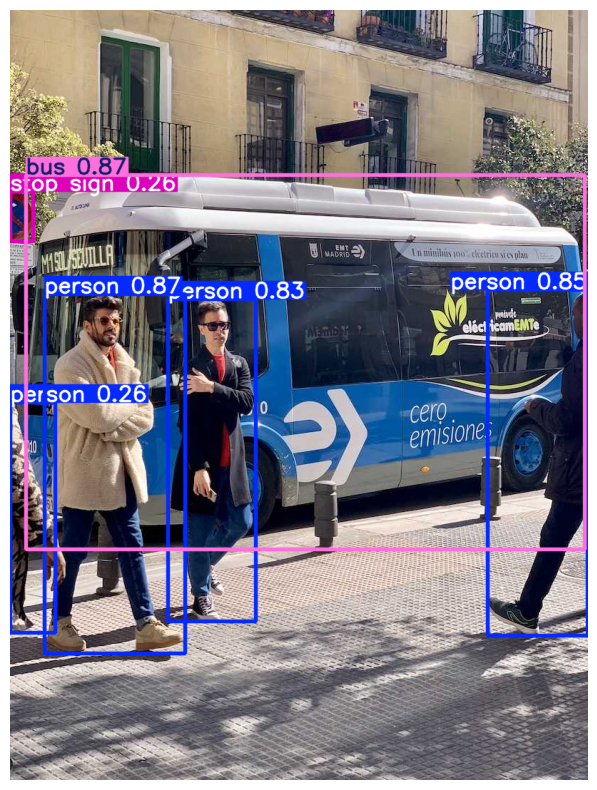

In [4]:
# Run inference on an image
results = model('https://ultralytics.com/images/bus.jpg')

# Process results
for r in results:
    # Print boxes to console
    print(r.boxes)
    
    # Plot results on the image
    im_array = r.plot()
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
    
    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()

## 4. Training on a Custom Dataset

To train YOLO on your own data, you need a dataset in the YOLO format (images and `.txt` labels). You also need a `data.yaml` file defining the paths and classes.

In [5]:
# Example training command (commented out as it requires a dataset)
# model.train(data='coco8.yaml', epochs=10, imgsz=640)

## 5. Exporting the Model

Once trained, you can export the model to various formats like ONNX, TensorRT, or CoreML for deployment.

In [6]:
# Export the model to ONNX format
# path = model.export(format='onnx')
# print(f"Model exported to: {path}")